In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from scipy import stats
from os.path import join
from pathlib import Path
import numpy as np
import pathlib
from typing import Dict, List

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

In [3]:
from utils import population_dict

In [4]:
from mylib import genomes
root_dir = join(Path.home(),"projects/cp_als/populations")

# Pick the focus Population so we can compare against

In [5]:
focused_population = "ESN"

In [6]:
compared_populations = ["ASW","ACB", "ITU", "BEB","GBR","CDX","CLM","KHV","FIN","GWD","GIH","CHB","CHS","IBS","JPT","LWK","MSL","MXL","PEL","PUR","PJL","STU","TSI","YRI"]

# Load variant data

In [7]:
#indir = join(Path.home(),"projects/cp_als/populations")
file_path = join(root_dir, f"output/{focused_population}/all.csv")
df = pd.read_csv(file_path)

In [8]:
genes = list(df['gene'].unique())
print(genes)

['TARDBP', 'C9ORF72', 'FUS', 'NEFH', 'C19ORF12', 'SIGMAR1', 'CHMP2B', 'CREST', 'SPG11', 'OPTN', 'DAO', 'SETX', 'ELP3', 'SOD1', 'PRPH', 'PFN1', 'FIG4', 'SQSTM1', 'hnRNPa1', 'TAF15', 'ERBB4', 'CHCHD10', 'ANG', 'hnRNPA2B1', 'PON1-3', 'ALS2', 'MATR3', 'TUBA4A', 'ATXN2', 'VAPB', 'EWSR1', 'VCP', 'DCTN1', 'CHRNA3', 'PNPLA6', 'NEK1']


In [9]:
populations = [c for c in genomes if c != focused_population]

# Create the 2D matrix for t-test p-values

In [10]:
hdf = pd.DataFrame(columns=populations,index=genes)
hdf

,ACB,ASW,BEB,CDX,CHB,CHS,CLM,FIN,GBR,GIH,...,KHV,LWK,MSL,MXL,PEL,PJL,PUR,STU,TSI,YRI
TARDBP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
C9ORF72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FUS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NEFH,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
C19ORF12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SIGMAR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CHMP2B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CREST,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SPG11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OPTN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
def get_total_variant_count(root_dir,important_gene,populations,genomes):
    total_variant_count = []
    for pop_name,genome_list in genomes.items():
        if pop_name not in populations:
            continue
        file_path = join(root_dir,f"output/{pop_name}/all.csv")
        df = pd.read_csv(file_path)
        df = df[df['gene'] == important_gene]
        filtered_genomes = [g for g in genome_list if g in df.columns]
        df_filtered = df[filtered_genomes]
        total_count = df_filtered.sum()
        total_variant_count.append(total_count.values)
    return total_variant_count

# Calcuate the t-test p-values

In [12]:
for important_gene in genes:
    for population in populations:
        population_pair = [focused_population, population]
        total_variant_count = get_total_variant_count(root_dir = root_dir, important_gene = important_gene,
                                                      populations = population_pair, genomes=genomes)
        t_statistic, p_value = stats.ttest_ind(total_variant_count[0],total_variant_count[1])
        hdf.at[important_gene,population_pair[1]] = p_value

In [13]:
hdf.dropna(axis=1,how='all',inplace=True)

In [14]:
hdf.dropna(axis=0,how='any',inplace=True)

In [15]:
hdf.shape

(36, 24)

# Check the resulting p-values 2D matrix

In [16]:
hdf

,ACB,ASW,BEB,CDX,CHB,CHS,CLM,FIN,GBR,GIH,...,KHV,LWK,MSL,MXL,PEL,PJL,PUR,STU,TSI,YRI
TARDBP,0.00073,0.039094,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.299792,0.086138,0.0,0.0,0.0,0.0,0.0,0.0,0.643697
C9ORF72,0.887877,0.058499,0.009487,0.000001,0.0,0.0,0.002107,0.309471,0.193078,0.083834,...,0.000029,0.119071,0.086778,0.001891,0.0,0.322754,0.010563,0.027846,0.004232,0.89162
FUS,0.849163,0.078003,0.005708,0.000095,0.0,0.000015,0.040453,0.000266,0.000061,0.010302,...,0.000193,0.022768,0.242647,0.028639,0.015715,0.009375,0.016759,0.00923,0.000783,0.167104
NEFH,0.998543,0.825157,0.000065,0.0,0.0,0.0,0.000001,0.021197,0.0,0.000052,...,0.0,0.10462,0.388357,0.000328,0.0,0.000022,0.000376,0.000445,0.000012,0.877037
C19ORF12,0.006774,0.364983,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.041504,0.508365,0.0,0.0,0.0,0.0,0.0,0.0,0.270758
SIGMAR1,0.807698,0.133534,0.000061,0.000197,0.000029,0.000001,0.0,0.000007,0.0,0.006496,...,0.000063,0.355466,0.14591,0.0,0.0,0.019124,0.0,0.000043,0.0,0.761662
CHMP2B,0.50748,0.149505,0.075866,0.006472,0.458672,0.020799,0.000417,0.000009,0.00002,0.043272,...,0.116874,0.017907,0.071288,0.284162,0.496138,0.002311,0.000014,0.035982,0.0,0.404011
CREST,0.286573,0.000078,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.237504,0.969624,0.0,0.0,0.0,0.0,0.0,0.0,0.308639
SPG11,0.612701,0.371829,0.001096,0.179632,0.070279,0.209333,0.0,0.0,0.0,0.0,...,0.148336,0.716306,0.902715,0.0,0.0,0.0,0.0,0.000003,0.0,0.052019
OPTN,0.337745,0.117728,0.005793,0.000019,0.0,0.000004,0.000046,0.0,0.000052,0.002431,...,0.000013,0.486315,0.817033,0.293826,0.000034,0.004007,0.00005,0.002416,0.000113,0.348223


In [17]:
hdf.columns

Index(['ACB', 'ASW', 'BEB', 'CDX', 'CHB', 'CHS', 'CLM', 'FIN', 'GBR', 'GIH',
       'GWD', 'IBS', 'ITU', 'JPT', 'KHV', 'LWK', 'MSL', 'MXL', 'PEL', 'PJL',
       'PUR', 'STU', 'TSI', 'YRI'],
      dtype='object')

# Removing two genes with repeats: ATXN2 and C9ORF72

In [18]:
hdf.drop(["ATXN2", "C9ORF72"], inplace=True)

In [19]:
hdf_float = hdf.apply(pd.to_numeric,errors='coerce')

In [20]:
hdf_rounded = hdf_float.round(3)
hdf_rounded = hdf_rounded[compared_populations]
hdf_rounded.shape


(34, 24)

In [21]:
# Define mapping
pop_to_continent = {
    "ASW": "Americas", "ACB": "Africa", "BEB": "South Asia", "GBR": "Europe",
    "CDX": "East Asia", "CLM": "Americas", "KHV": "East Asia", "FIN": "Europe",
    "GWD": "Africa", "GIH": "South Asia", "CHB": "East Asia", "CHS": "East Asia",
    "IBS": "Europe", "JPT": "East Asia", "LWK": "Africa", "MSL": "Africa",
    "MXL": "Americas", "PEL": "Americas", "PUR": "Americas",
    "PJL": "South Asia", "STU": "South Asia", "ITU": "South Asia", "TSI": "Europe", "YRI": "Africa"
}

compared_populations_sorted = sorted(compared_populations, key=lambda x: pop_to_continent[x])
hdf_rounded = hdf_rounded[compared_populations_sorted]
continent_order = [pop_to_continent[p] for p in compared_populations_sorted]

In [22]:
from matplotlib.colors import BoundaryNorm

bounds = [0,0.051,0.1,0.5,0.75,1.0]
cmap = plt.cm.get_cmap("Greens_r", len(bounds)-1)
norm = BoundaryNorm (boundaries=bounds,ncolors = cmap.N)

/var/folders/mk/qv7kjtr17ls_fqfn64hdptt00000gn/T/ipykernel_85748/722416586.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Greens_r", len(bounds)-1)


# Plot the heatmap

/var/folders/mk/qv7kjtr17ls_fqfn64hdptt00000gn/T/ipykernel_85748/937884780.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_data = hdf_subset.applymap(format_value)
/var/folders/mk/qv7kjtr17ls_fqfn64hdptt00000gn/T/ipykernel_85748/937884780.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Greens_r", len(bounds)-1)


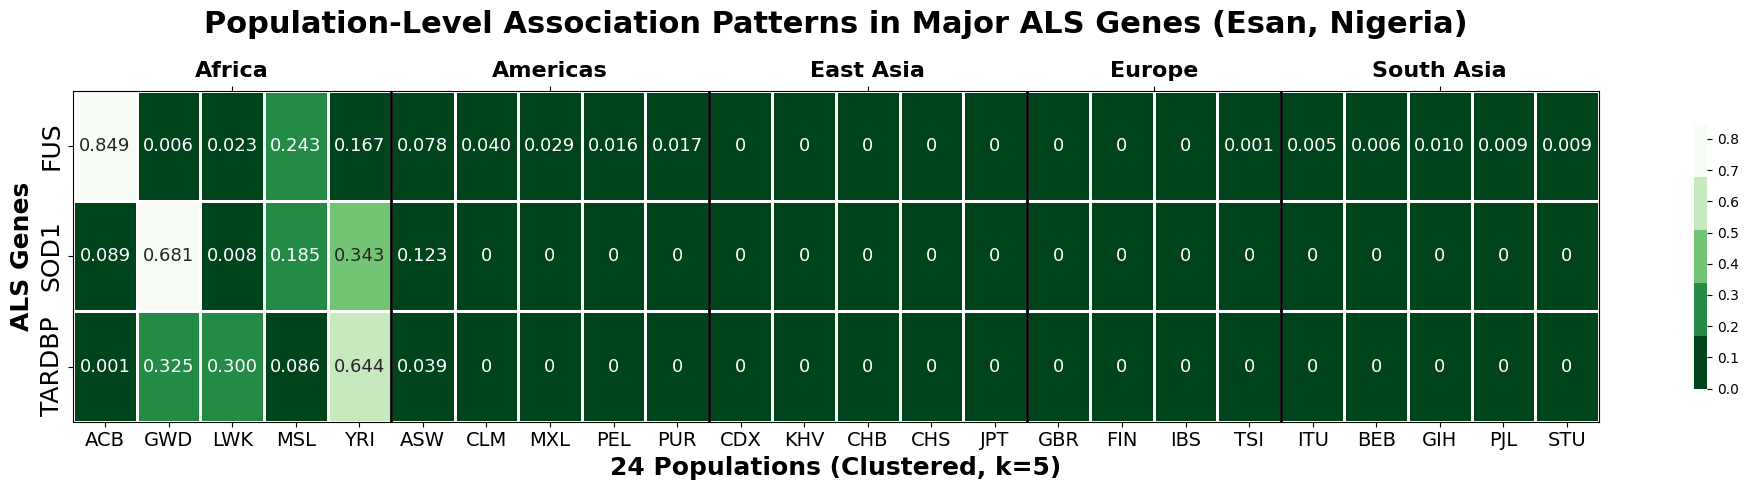

Saved: plots/als_major_genes_heatmap.png


In [27]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------------
# Filter to selected genes
# -----------------------------------
selected_genes = ["FUS", "SOD1", "TARDBP"]
hdf_subset = hdf_rounded.loc[selected_genes]

# -----------------------------------
# Format annotations: 0.0000 → "0"
# -----------------------------------
def format_value(x):
    if np.isclose(x, 0):
        return "0"
    return f"{x:.3f}"

annot_data = hdf_subset.applymap(format_value)

# -----------------------------------
# Create folder if needed
# -----------------------------------
os.makedirs("plots", exist_ok=True)

# -----------------------------------
# Plot
# -----------------------------------
plt.figure(figsize=(20, 5))

bounds = [0,0.051,0.1,0.5,0.75,1.0]
cmap = plt.cm.get_cmap("Greens_r", len(bounds)-1)
norm = BoundaryNorm (boundaries=bounds,ncolors = cmap.N)

ax = sns.heatmap(
    hdf_subset,
    # cmap="viridis",
    cmap=cmap,
    annot=annot_data,
    fmt="",
    annot_kws={"size": 13},
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"shrink": 0.8}
)

# -----------------------------------
# Vertical continent separators
# -----------------------------------
boundaries = [
    i for i in range(1, len(continent_order))
    if continent_order[i] != continent_order[i - 1]
]

for b in boundaries:
    ax.axvline(b, color="black", linewidth=2)

# -----------------------------------
# Continent labels on top
# -----------------------------------
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())

group_positions = []
group_labels = []

for cont, pops in pd.Series(continent_order).groupby(continent_order):
    mid = (pops.index[0] + pops.index[-1]) / 2
    group_positions.append(mid + 0.5)
    group_labels.append(cont)

ax2.set_xticks(group_positions)
ax2.set_xticklabels(group_labels, rotation=0, fontsize=16, fontweight="bold")

# -----------------------------------
# Titles and labels
# -----------------------------------
plt.title(
    # f"Heatmap of t-test pvalue for Major ALS Genes ({population_dict[focused_population]})",
    f"Population-Level Association Patterns in Major ALS Genes ({population_dict[focused_population]})",
    fontsize=22,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    f"{hdf_subset.shape[1]} Populations (Clustered, k=5)",
    fontsize=18,
    fontweight="bold"
)

ax.set_ylabel(
    "ALS Genes",
    fontsize=18,
    fontweight="bold"
)

ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=18)

plt.tight_layout()

# -----------------------------------
# Save
# -----------------------------------
output_file = "plots/als_major_genes_heatmap.png"
plt.savefig(output_file, dpi=400, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved: {output_file}")